In [7]:
import metaworld
import os
import pickle

name = "reach"
seed = 1
size = (64, 64)
action_repeat = 2
camera = "test"
os.environ["MUJOCO_GL"] = "egl"

# Construct the benchmark, sampling tasks
ml1 = metaworld.ML1(f'{name}-v2', seed=seed) 

# Create an environment with task `pick_place`
env_cls = ml1.train_classes[f'{name}-v2']  
_env = env_cls()
_env._freeze_rand_vec = False
_size = size
_action_repeat = action_repeat
_camera = camera
_seed = seed
_tasks = ml1.test_tasks
if name == 'reach':
    with open(f'mw_tasks/{seed}.pickle', 'rb') as handle:
        _tasks = pickle.load(handle)

In [ ]:
%matplotlib inline

In [1]:
import os
os.environ["DISPLAY"] = ":99"

import gym
import rlbench.gym

In [2]:
import os
os.environ["DISPLAY"] = ":99"

import gym
import rlbench.gym
import time

env = gym.make('reach_target-state-v0', render_mode='human', headless=True)
# Alternatively, for vision:
# env = gym.make('reach_target-vision-v0')

training_steps = 120
episode_length = 40
# time.
for i in range(training_steps):
    if i % episode_length == 0:
        print('Reset Episode')
        obs = env.reset()
    obs, reward, terminate, _ = env.step(env.action_space.sample())
    # env.render()  # Note: rendering increases step time.

print('Done')
env.close()

Reset Episode
Reset Episode
Reset Episode
Done
[CoppeliaSim:loadinfo]   done.


In [ ]:
from vima_bench import make

env = make(task_name="visual_manipulation")

obs = env.reset()
prompt, prompt_assets = env.prompt, env.prompt_assets

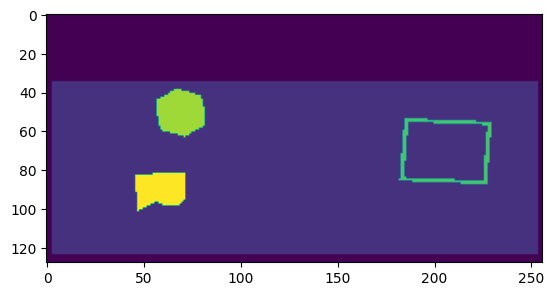

In [14]:
import matplotlib.pyplot as plt

plt.imshow(obs["segm"]["front"])#.transpose(1,2,0))

No protocol specified
[2023-04-20 12:29:22.571] [svulkan2] [error] GLFW error: X11: Failed to open display :0
[2023-04-20 12:29:22.571] [svulkan2] [warning] Continue without GLFW.
No protocol specified


Action Space: Box([-1. -1. -1. -1. -1. -1. -1. -1.], [1. 1. 1. 1. 1. 1. 1. 1.], (8,), float32)


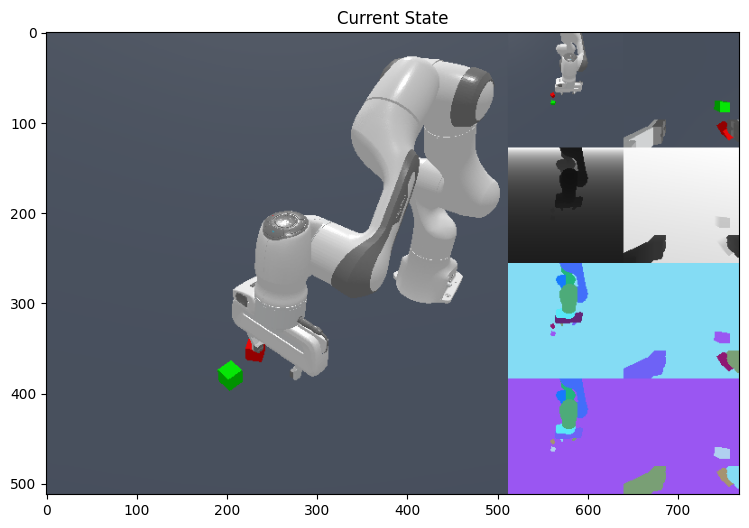

In [4]:
# get segmentation masks
# get depth
# get objects property separately
# 
import os
# Import required packages
import gym
from tqdm.notebook import tqdm
import numpy as np
import mani_skill2.envs
import matplotlib.pyplot as plt

os.environ["MUJOCO_GL"] = "egl"
os.environ["DISPLAY"] = ":0"

# This tutorial allows you to play with 4 environments out of a total of 20 environments that ManiSkill provides
env_id = "StackCube-v0" #@param ['PickCube-v0', 'PegInsertionSide-v0', 'StackCube-v0', 'PlugCharger-v0']

# choose an observation type and space, see https://haosulab.github.io/ManiSkill2/concepts/observation.html for details
obs_mode = "state_dict" #@param can be one of ['pointcloud', 'rgbd', 'state_dict', 'state']

# choose a controller type / action space, see https://haosulab.github.io/ManiSkill2/concepts/controllers.html for a full list
control_mode = "pd_joint_delta_pos" #@param can be one of ['pd_ee_delta_pose', 'pd_ee_delta_pos', 'pd_joint_delta_pos', 'arm_pd_joint_pos_vel']

reward_mode = "dense" #@param can be one of ['sparse', 'dense']

# create an environment with our configs and then reset to a clean state
env = gym.make(env_id, obs_mode=obs_mode, reward_mode=reward_mode, control_mode=control_mode, camera_cfgs={"add_segmentation": True})

obs = env.reset()
print("Action Space:", env.action_space)
# take a look at the current state
img = env.render(mode="cameras")
plt.figure(figsize=(10,6))
plt.title("Current State")
plt.imshow(img)
# env.close()

Action Space: Box([-1. -1. -1. -1. -1. -1. -1. -1.], [1. 1. 1. 1. 1. 1. 1. 1.], (8,), float32)


[2023-04-20 12:29:25.453] [svulkan2] [warning] A second renderer will share the same internal context with the first one. Arguments passed to constructor will be ignored.


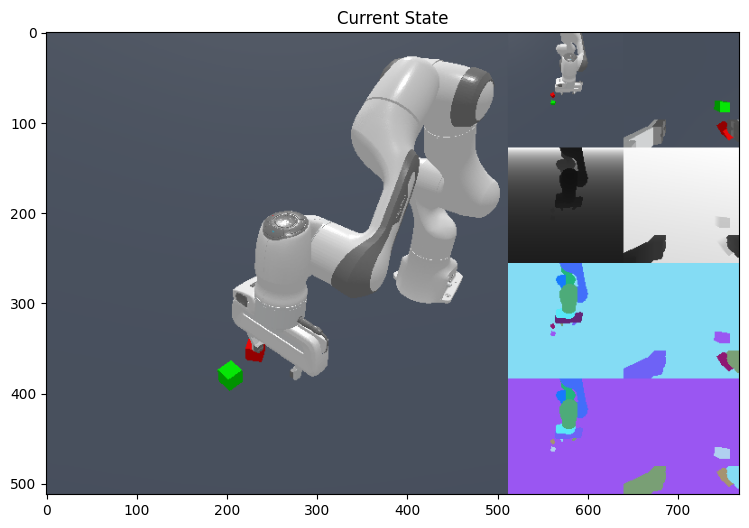

In [5]:
# This tutorial allows you to play with 4 environments out of a total of 20 environments that ManiSkill provides
env_id = "StackCube-v0" #@param ['PickCube-v0', 'PegInsertionSide-v0', 'StackCube-v0', 'PlugCharger-v0']

# choose an observation type and space, see https://haosulab.github.io/ManiSkill2/concepts/observation.html for details
obs_mode = "state_dict" #@param can be one of ['pointcloud', 'rgbd', 'state_dict', 'state']

# choose a controller type / action space, see https://haosulab.github.io/ManiSkill2/concepts/controllers.html for a full list
control_mode = "pd_joint_delta_pos" #@param can be one of ['pd_ee_delta_pose', 'pd_ee_delta_pos', 'pd_joint_delta_pos', 'arm_pd_joint_pos_vel']

reward_mode = "dense" #@param can be one of ['sparse', 'dense']

# create an environment with our configs and then reset to a clean state
env = gym.make(env_id, obs_mode=obs_mode, reward_mode=reward_mode, control_mode=control_mode, camera_cfgs={"add_segmentation": True, "texture_names": ("Color", "Position", "Segmentation")})

obs = env.reset()
print("Action Space:", env.action_space)
# take a look at the current state
img = env.render(mode="cameras")
plt.figure(figsize=(10,6))
plt.title("Current State")
plt.imshow(img)
# env.close()

In [9]:
print(env.get_actors())
target_object_actor_ids = [x.id for x in env.get_actors() if x.name not in ['ground', 'goal_site']]
print(target_object_actor_ids)
# print(obs["image"]["base_camera"]["Position"].shape)

# plt.imshow(obs["image"]["base_camera"]["depth"])

[Actor(name="ground", id="14"), Actor(name="cubeA", id="15"), Actor(name="cubeB", id="16")]
[15, 16]


In [57]:
print(obs.keys())
print(obs["extra"].keys())
print(obs["agent"].keys())

for k, v in obs["agent"].items():
    print(k, v.shape)
    
for k, v in obs["extra"].items():
    print(k, v.shape)
    
print(img.keys())
# print(obs["camera_param"]["base_camera"]["extrinsic_cv"])
# print(obs["camera_param"]["base_camera"]["cam2world_gl"])
# print(obs["camera_param"]["base_camera"]["intrinsic_cv"])

# print(env.reward_scale)

odict_keys(['agent', 'extra'])
odict_keys(['tcp_pose', 'cubeA_pose', 'cubeB_pose', 'tcp_to_cubeA_pos', 'tcp_to_cubeB_pos', 'cubeA_to_cubeB_pos'])
odict_keys(['qpos', 'qvel', 'base_pose'])
qpos (9,)
qvel (9,)
base_pose (7,)
tcp_pose (7,)
cubeA_pose (7,)
cubeB_pose (7,)
tcp_to_cubeA_pos (3,)
tcp_to_cubeB_pos (3,)
cubeA_to_cubeB_pos (3,)


AttributeError: 'numpy.ndarray' object has no attribute 'keys'

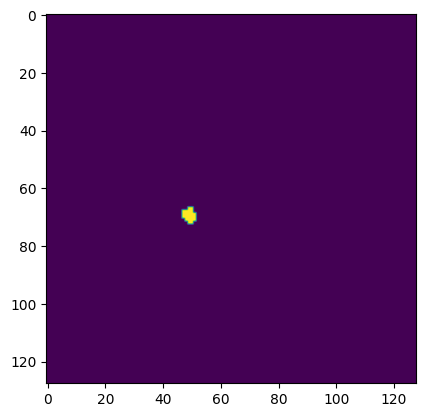

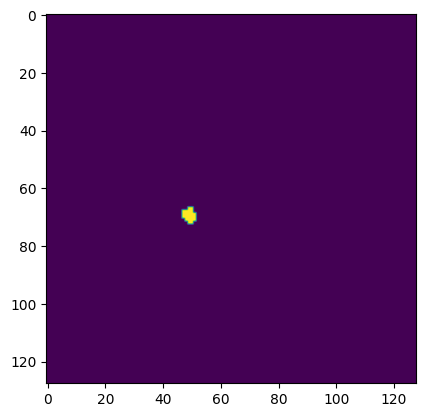

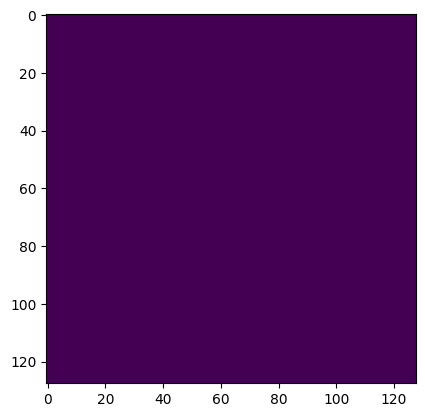

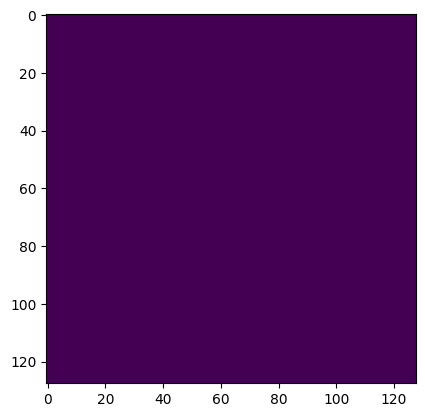

[[[0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]
  ...
  [0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]]

 [[0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]
  ...
  [0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]]

 [[0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]
  ...
  [0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]]

 ...

 [[0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]
  ...
  [0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]]

 [[0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]
  ...
  [0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]]

 [[0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]
  ...
  [0 0 0 0]
  [0 0 0 0]
  [0 0 0 0]]]


In [15]:
rgb = env.get_images()["base_camera"]["Color"]
# depth = env.get_images()["base_camera"]["Position"]

import matplotlib.pyplot as plt
seg = env.get_images()["base_camera"]["Segmentation"]

id_objs = np.expand_dims(seg[:,:,1] == 15, axis=-1)

seg *= id_objs
for i in range(seg.shape[-1]):
    plt.imshow(seg[:,:,i])
    plt.show()
# plt.imshow(seg[:,:,0])
# plt.show()
# print(env.observation_space)

print(seg)

In [18]:
print(dir(env.env))
print()

['SUPPORTED_OBS_MODES', 'SUPPORTED_REWARD_MODES', 'SUPPORTED_ROBOTS', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_actors', '_add_ground', '_after_simulation_step', '_agent_camera_cfgs', '_agent_cfg', '_articulations', '_before_control_step', '_build_cube', '_build_sphere_site', '_camera_cfgs', '_cameras', '_check_cubeA_on_cubeB', '_clear', '_clear_sim_state', '_close_viewer', '_configure_agent', '_configure_cameras', '_configure_render_cameras', '_control_freq', '_control_mode', '_elapsed_steps', '_engine', '_episode_rng', '_episode_seed', '_get_default_scene_config', '_get_obs_agent', '_get_obs_extra', '_get_obs_images', '_get_obs_state_dict', '